In [57]:
# 01. 공통 코드
# 공통 처리

# 불필요한 경고 메시지 무시
import warnings
warnings.filterwarnings("ignore")

# 라이브러리 임폴트
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 한글 글꼴 설정
import platform
from matplotlib import rc


if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    rc('font', family='Malgun Gothic')
else:
    rc('font', family='Malgun Gothic')

# 데이터프레임 출력용 함수
from IPython.display import Image

# 숫자 출력 조정
# 넘파이 부동소수점 출력 자리수 설정
np.set_printoptions(suppress=True, precision=4)

# 판다스 부동소수점 출력 자리수 설정
pd.options.display.float_format = '{:,.4f}'.format

# 데이터 프레임 모든 필드 출력
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# 그래프 글꼴 크기 설정
plt.rcParams['font.size'] = 14

# 난수 시드
random_seed = 123

In [58]:
# 1. 데이터 확인
# 모델을 구축하는 첫 단계는 학습에 사용할 데이터를 확인하는 것

# 데이터를 확인하는 방법
# 1) 데이터프레임의 기능을 통해 수치적, 통계적으로 분석하는 방법
# 누락 값 조사, 필드 값의 개수, 평균, 표준편차들을 조사
# 2) matplotlib 이나 seaborn 같은 시각화 라이브러리를 사용해 시각적으로 분석 및 확인하는 방법
# 필드 단위로 히스토그램을 그리거나 두 개 필드 사이의 관계를 알 수 있는 산점도를 확인

# 01. 수치적, 통계적으로 분석하는 방법
# 1) 타이타닉 데이터 집합
# 영화 타이타닉으로 유명한 여객선 타이타닉호의 승객명단
# 일반적인 명단이 들어가는 정보와 함께 해당 승객의 침몰 후 생존 여부 필드롤 포함

# 이 데이터의 장점
# * 데이터 필드 수가 적당하다
# * 누락 값이 있다. (누락 값을 확인할 필요가 생긴다.)
# * 숫자로 된 필드와 문자열로 된 필드가 섞여 있어 다양한 통계 처리를 시험해 보기 좋다

# 1) 데이터 읽어 들이기
# seaborn 라이브러리에서 제공하는 load_dataset() 함수를 사용하면 간단하게 데이터를 얻을 수 있음

# 추가 라이브러리 임포트
import seaborn as sns

# 데이터 읽어 들이기
df_titanic = sns.load_dataset("titanic")
print(df_titanic.head())

   survived  pclass     sex     age  sibsp  parch    fare embarked  class  \
0         0       3    male 22.0000      1      0  7.2500        S  Third   
1         1       1  female 38.0000      1      0 71.2833        C  First   
2         1       3  female 26.0000      0      0  7.9250        S  Third   
3         1       1  female 35.0000      1      0 53.1000        S  First   
4         0       3    male 35.0000      0      0  8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [59]:
# 한국어로 필드 정의

columns_t = ['생존', '선실등급', '성별', '나이', '형제_및_배우자_수', '부모_및_자녀_수','요금','승선항_코드','선실등급명','남녀어린이_구분', '성인_남성_여부', '선실번호', '승선항','생존_여부','독신_여부']
df_titanic.columns = columns_t
print(df_titanic.head())

   생존  선실등급      성별      나이  형제_및_배우자_수  부모_및_자녀_수      요금 승선항_코드  선실등급명  \
0   0     3    male 22.0000           1          0  7.2500      S  Third   
1   1     1  female 38.0000           1          0 71.2833      C  First   
2   1     3  female 26.0000           0          0  7.9250      S  Third   
3   1     1  female 35.0000           1          0 53.1000      S  First   
4   0     3    male 35.0000           0          0  8.0500      S  Third   

  남녀어린이_구분  성인_남성_여부 선실번호          승선항 생존_여부  독신_여부  
0      man      True  NaN  Southampton    no  False  
1    woman     False    C    Cherbourg   yes  False  
2    woman     False  NaN  Southampton   yes   True  
3    woman     False    C  Southampton   yes  False  
4      man      True  NaN  Southampton    no   True  


In [60]:
# 3) 누락값 조사하기
# 머신러닝 모델을 구축할때 누락 값이 있는 것은 모델의 정확도를 떨어트리는 큰 원인이 된다.
# 데이터에서 누락 값이 얼마나 많은지 확인하는 것이 중요

# 02. 누락값 확인하기
# isnull()함수를 사용
print(df_titanic.isnull().sum())
# 나이, 승선항_코드, 선실번호, 승선항 4개의 필드에 누락 값이 포함
# 전체 869건이라 2건은 적은 수라서 행 전체를 삭제(승선항_코드는 날림)
# 연령, 승선형_코드, 선실번호만 작업


# 4) 필드 값의 개수를 집계
# '승선항' 필드의 필드 값 개수를 집계
# '생존_여부' 필드의 필드 값 개수를 집계

print(df_titanic['승선항'].value_counts(dropna=False))
print(df_titanic['생존_여부'].value_counts(dropna=False))
# dropna=False 결측치 뽑아냄

# 5) 통계 정보 조사하기
display(df_titanic.describe())

# 6) 에그리게이션 함수 사용하기
# sex = df_titanic.groupby('성별', as_index=False).agg(sum=('성별','sum'))
# print(sex)
display(df_titanic.groupby('성별').mean(numeric_only=True))

생존              0
선실등급            0
성별              0
나이            177
형제_및_배우자_수      0
부모_및_자녀_수       0
요금              0
승선항_코드          2
선실등급명           0
남녀어린이_구분        0
성인_남성_여부        0
선실번호          688
승선항             2
생존_여부           0
독신_여부           0
dtype: int64
승선항
Southampton    644
Cherbourg      168
Queenstown      77
NaN              2
Name: count, dtype: int64
생존_여부
no     549
yes    342
Name: count, dtype: int64


,생존,선실등급,나이,형제_및_배우자_수,부모_및_자녀_수,요금
count,891.0000,891.0000,714.0000,891.0000,891.0000,891.0000
mean,0.3838,2.3086,29.6991,0.5230,0.3816,32.2042
std,0.4866,0.8361,14.5265,1.1027,0.8061,49.6934
min,0.0000,1.0000,0.4200,0.0000,0.0000,0.0000
25%,0.0000,2.0000,20.1250,0.0000,0.0000,7.9104
50%,0.0000,3.0000,28.0000,0.0000,0.0000,14.4542
75%,1.0000,3.0000,38.0000,1.0000,0.0000,31.0000
max,1.0000,3.0000,80.0000,8.0000,6.0000,512.3292


,생존,선실등급,나이,형제_및_배우자_수,부모_및_자녀_수,요금,성인_남성_여부,독신_여부
성별,,,,,,,,
female,0.7420,2.1592,27.9157,0.6943,0.6497,44.4798,0.0000,0.4013
male,0.1889,2.3899,30.7266,0.4298,0.2357,25.5239,0.9307,0.7123


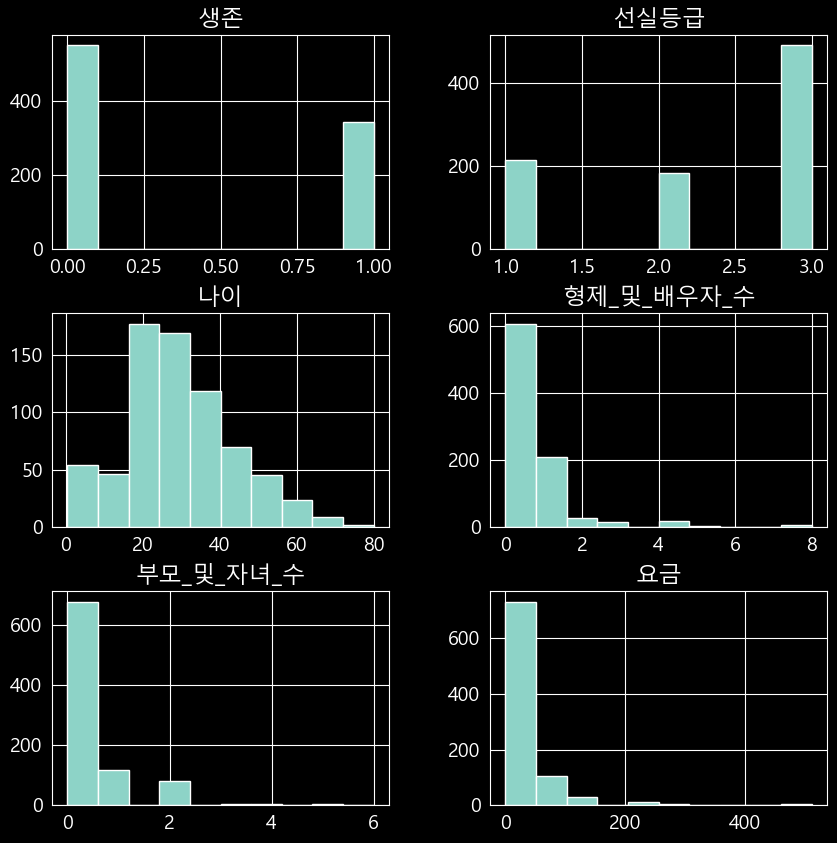

In [61]:
# 그래프 그리기

# 숫자 필드 필드명 정의
columns_n = ['생존', '선실등급', '나이', '형제_및_배우자_수', '부모_및_자녀_수', '요금']

# 그래프 작도 영역 조정
plt.rcParams['figure.figsize']=(10,10)

# 데이터프레임 숫자 필드에 대해 히스토그램을 출력
df_titanic[columns_n].hist()
plt.show()

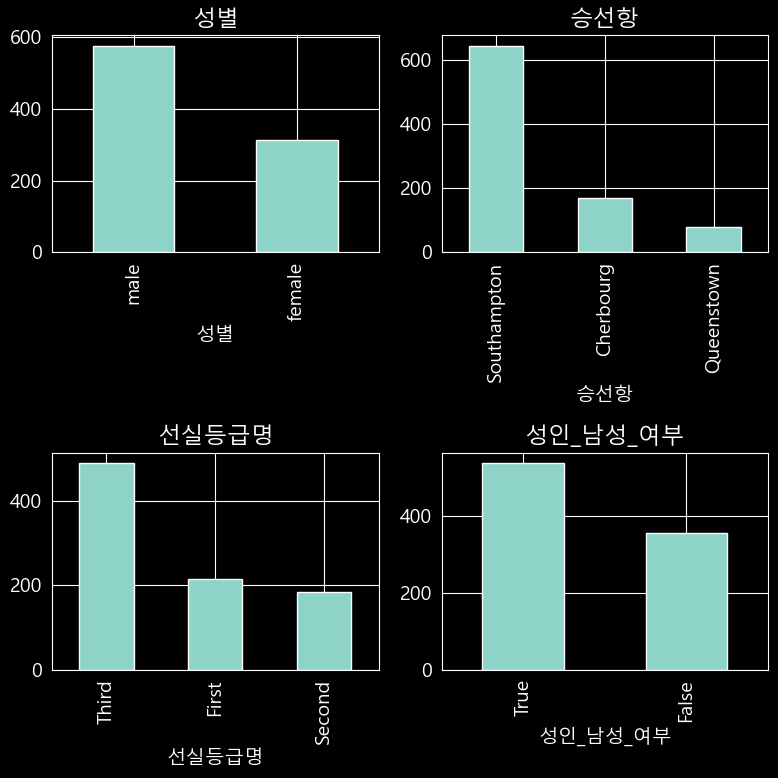

In [62]:
# 8) 숫자 값이 아닌 필드에 대한 그래프 그리기

columns_c = ['성별', '승선항', '선실등급명', '성인_남성_여부']

# 그래프 작도 영역 조정
plt.rcParams['figure.figsize']=(8,8)

# 반복문
for i, name in enumerate(columns_c):
    ax = plt.subplot(2,2,i+1)
    df_titanic[name].value_counts().plot(kind='bar',title=name,ax=ax)

# 레이아웃조정
plt.tight_layout()
plt.show()

In [63]:
# 01. 불필요한 필드 삭제하기
# 선실등급(pclass)과 선실등급명(class), 승선항 코드(embarked)와 승선항(embark_town),
# 생존(survival)과 생존 여부(alive)는 각각 의미가 같은 중복 코드
# 머신러닝 모델을 ㅁ나들 때 같은 정보를 담은 데이터 필드가 여러 개 있으면 오히려 정확도가 떨어지기도 함
# 중복되는 필드를 삭제하는 것이 중요

# 중복되는 필드 중 남길 필드는 순서가 있는 숫자형을 남기는 편이 좋음
# 예를 들어 선실등급(1, 2, 3)과 선실등급명(First, Second, Third)의 경우 순서가 있는 필드가 우선
# 값이 두 종류이고 어느 한쪽이 0/1로 값을 나타낸다면 해당 필드를 우성. (생존/ 생존 여부)
# 그 이외에는 어느것을 선택해도 무방하므로 구현의 편의성과 사람이 이해하기 유리한 것을 고려해 선택.(승선항코드 / 승선항)
# 승선항코드 / 승선항의 경우 원 핫 인코딩시에 필드명을 짧게 유지할 수 있게 승선항 코드를 남김.


In [64]:
# 선실등급명 (선실등급과 중복)
df1 = df_titanic.drop('선실등급명', axis=1) # axis=1: 가로방향

# "승선항" ("승선항 코드"과 중복)
df2 = df1.drop('승선항', axis=1) # axis=1: 가로방향

# "생존_여부" ("생존"과 중복)
df3 = df2.drop('생존_여부', axis=1) # axis=1: 가로방향

# 결과 확인
display(df3.head())

,생존,선실등급,성별,나이,형제_및_배우자_수,부모_및_자녀_수,요금,승선항_코드,남녀어린이_구분,성인_남성_여부,선실번호,독신_여부
0,0,3,male,22.0000,1,0,7.2500,S,man,True,NaN,False
1,1,1,female,38.0000,1,0,71.2833,C,woman,False,C,False
2,1,3,female,26.0000,0,0,7.9250,S,woman,False,NaN,True
3,1,1,female,35.0000,1,0,53.1000,S,woman,False,C,False
4,0,3,male,35.0000,0,0,8.0500,S,man,True,NaN,True


In [65]:
# 현재 데이터를 보니 선실번호에 누락값이 있는 상태
# 전체 데이터 건수의 누락값이 많은 상태이므로 행 전체를 삭제하기 보단 누락값을 채워넣는 방식으로 작업해볼 것
# 문자열이라서 일단 분포를 살펴봄

# display(df3['선실번호'].value_counts())
print(df3['선실번호'].value_counts())

선실번호
C    59
B    47
D    33
E    32
A    15
F    13
G     4
Name: count, dtype: int64


In [66]:
# 필드의 값은 숫자가 아니라 A부터 G까지의 알파벳 문제
# 이런 경우에는 누락 값을 의미하는 별도의 코드(이를테면 N)을 할당하는 방법이 가장 일반적

# 승선항_코드 : 누락값이 2건 -> 행 전체를 삭제
# dropna 함수를 사용
df4 = df3.dropna(subset={'승선항_코드'})

# 나이, 선실번호에서 데이터 누락값이 많은 상태

# 나이: 숫자 데이터이며 누락값 필드 값의 평균값으로 누락값을 대체

# 평균값 계산
age_average = df3['나이'].mean()

# fillna 함수를 사용
df4 = df3.fillna({'나이': age_average})

# 선실번호 : 코드값 필드이며 누락값이 많은 상태 -> 누락값을 의미하는 더미 코드를 부여함

# replace 함수를 사용 (더미코드는 N)
df4['선실번호'] = df4['선실번호'].astype(np.str_)
df5 = df4.replace({'선실번호':{'nan': 'N'}})

# 누락값을 포함한 행 전체를 삭제하려면 dropna 함수를 사용
# 누락값을 대체하려면 fillna() 함수를 사용

# 결과 확인
# display(df5.isnull().sum())
print(df5.isnull().sum())

생존            0
선실등급          0
성별            0
나이            0
형제_및_배우자_수    0
부모_및_자녀_수     0
요금            0
승선항_코드        2
남녀어린이_구분      0
성인_남성_여부      0
선실번호          0
독신_여부         0
dtype: int64


In [67]:
# 03. 이전 레이블값 필드를 숫자 값 필드로 만들기
# 레이블값 필드 : 타이타닉 데이터 집합의 필드 중 성별 필드는 male / female 두 가지 문자열을 값으로 가짐
# 이렇게 정해진 종류의 문자열만을 값으로 갖는 필드

# 레이블값 필드는 별도의 가공없이는 머신러닝 모델에 입력할 수 없어서 '레이블 값 필드를 숫자값 필드로 변환' 하는 과정이 데이터 전처리에 포함

# 성별 필드처럼 값이 두 가지뿐인 레이블을 이진 레이블이라 하고, 이진 레이블은 숫자로 변환하기 비교적 쉬움
# 대게는 1/ 0 으로 변환

# 데이터 전처리 중인 데이터 집합(df5)에서 이진 레이블값 필드는 성별: male/ female, 성인_남성_여부 : True / False,
# 독신_여부 : True / False 세 개의 필드

# 성별 : male / female
# 성인_남성_여부 : True / False
# 독신_여부 : True / False
# 위 필드의 값을 각각 1 / 0 필드로 변환

print(df5['성별'].value_counts())

성별
male      577
female    314
Name: count, dtype: int64


In [68]:
# 딕셔너리 mf_map을 정의
mf_map = {'male':1, 'female':0}

# map 함수를 사용해 레이블을 수치로 변환
df6 = df5.copy()
df6['성별'] = df6['성별'].map(mf_map)
print(df6['성별'].value_counts())

성별
1    577
0    314
Name: count, dtype: int64


In [69]:
# print(df6.head())
display(df6.head())

,생존,선실등급,성별,나이,형제_및_배우자_수,부모_및_자녀_수,요금,승선항_코드,남녀어린이_구분,성인_남성_여부,선실번호,독신_여부
0,0,3,1,22.0000,1,0,7.2500,S,man,True,N,False
1,1,1,0,38.0000,1,0,71.2833,C,woman,False,C,False
2,1,3,0,26.0000,0,0,7.9250,S,woman,False,N,True
3,1,1,0,35.0000,1,0,53.1000,S,woman,False,C,False
4,0,3,1,35.0000,0,0,8.0500,S,man,True,N,True


In [71]:
# 2) '성인_남성_여부', '독십_여부' 필드를 숫자 값 필드로 변환
print(df6['성인_남성_여부'].value_counts())

성인_남성_여부
True     537
False    354
Name: count, dtype: int64


In [72]:
# 딕셔너리 tf_map을 정의
tf_map = {True:1, False:0}

# map 함수를 사용해 레이블을 수치로 변환
df7 = df6.copy()
df7['성인_남성_여부'] = df7['성인_남성_여부'].map(tf_map)

# map 함수를 사용해 레이블을 수치로 변환
df8 = df7.copy()
df7['독신_여부'] = df7['독신_여부'].map(tf_map)

# 결과확인
display(df8.head())

,생존,선실등급,성별,나이,형제_및_배우자_수,부모_및_자녀_수,요금,승선항_코드,남녀어린이_구분,성인_남성_여부,선실번호,독신_여부
0,0,3,1,22.0000,1,0,7.2500,S,man,1,N,False
1,1,1,0,38.0000,1,0,71.2833,C,woman,0,C,False
2,1,3,0,26.0000,0,0,7.9250,S,woman,0,N,True
3,1,1,0,35.0000,1,0,53.1000,S,woman,0,C,False
4,0,3,1,35.0000,0,0,8.0500,S,man,1,N,True


In [75]:
# 04. 다중 레이블값 필드를 숫자값 필드로 만들기
# 원-핫 인코딩
# 레이블이 세 가지 이상인 다중 레이블값 필드를 숫자 값 필드로 변환하는 방법
# 직관적으로 다중 레이블 역시 0,1,2와 같이 여러 개의 숫자를 할당하는 방법보다는 원 핫 인코딩 one-hot encoding을 많이 사용
# 숫자 값으로 변경하면 자동으로 대소 관계가 결정
# 원-핫 인코딩을 인코딩된 데이터의 차원은 필드 값 종류의 수와 같음
# 즉, 각 레이블에 대응하는 열을 만들고 해당하는 열의 값은 1, 관계없는 열을 0을 부여

# 반대로 높은, 중간, 낮음 처럼 다중 레이블이면서도 절대적인 순서 관계가 있다면 원-핫 인코딩을 사용하지 않아도 됨

# 원-핫 인코딩에 주의할 점은 머신러닝 모델은 입력 데이터의 필드 수가 너무 많으면 학습이 잘 되지 않은 경향이 있음
# 예를 들어 학습 데이터의 입력 필드 중 필드값이 1000가지인 필드에 원-핫 인코딩을 적용하면
# 필드수가 1000개가 되어 입력디 값자기 1000차원이 되는 것과 마찬가지라서 학습이 잘 되지 않을 위험이 있음

# 또 학습이 잘 되더라도 필드 수가 늘어난 만큼 더 많은 학습 데이터가 필요하게 됨
# 그로 인해 머신러닝에서 가장 중요하면서도 비용이 많이 드는 학습 데이터 수집 작업의 부하가 커짐

# get_dummies() 함수 사용하기
# 데이터 프레임의 get_dummies() 함수 사용하기

# 변환 전
print(df8['남녀어린이_구분'].head(10))

0      man
1    woman
2    woman
3    woman
4      man
5      man
6      man
7    child
8    woman
9    child
Name: 남녀어린이_구분, dtype: str


In [77]:
# 변환
w = pd.get_dummies(df8['남녀어린이_구분'],prefix='남녀어린이_구분')
print(w.head(10))

   남녀어린이_구분_child  남녀어린이_구분_man  남녀어린이_구분_woman
0           False          True           False
1           False         False            True
2           False         False            True
3           False         False            True
4           False          True           False
5           False          True           False
6           False          True           False
7            True         False           False
8           False         False            True
9            True         False           False


In [78]:
# get_dummies 함수는 데이터프레임의 특정 열(남녀어린이_구분)을 인자로 받음
# 옵션 인자 prefix가 있어서 자동으로 생성되는 열의 이름 앞에 지정한 문자열을 붙일 수 있음
# 이 옵션은 필드 값이 중복되는 여러 필드에 원-핫 인코딩을 적용할 때 유용
# 실제 학습 데이터를 다룰때는 이렇게 인코딩된 열을 학습 데이터로 추가하고 그 대신 원래 있던 필드를 삭제


In [79]:
def enc(df, column):
    '''get_dummies 함수를 사용해 정의한 범주값을 원-핫 벡터로 변환하는 함수
    df : 대상 데이터프레임, column : 대상 필드'''
    # 원 -핫 벡터 생성
    df_dummy = pd.get_dummies(df[column], prefix=column)
    # 기존 필드 삭제
    df_drop = df.drop([column], axis=1)
    # 데이터 프레임과 원 - 핫 인코딩 필드를 결합
    df_1 = pd.concat([df_drop, df_dummy], axis=1)
    return df_1

In [80]:
# 남녀 어린이_구분
# man / woman / child

# 레이블 값 확인하기
display(df8['남녀어린이_구분'].value_counts())

df9 = enc(df8, '남녀어린이_구분')

# 결과 확인하기
display(df9.head())

남녀어린이_구분
man      537
woman    271
child     83
Name: count, dtype: int64

,생존,선실등급,성별,나이,형제_및_배우자_수,부모_및_자녀_수,요금,승선항_코드,성인_남성_여부,선실번호,독신_여부,남녀어린이_구분_child,남녀어린이_구분_man,남녀어린이_구분_woman
0,0,3,1,22.0000,1,0,7.2500,S,1,N,False,False,True,False
1,1,1,0,38.0000,1,0,71.2833,C,0,C,False,False,False,True
2,1,3,0,26.0000,0,0,7.9250,S,0,N,True,False,False,True
3,1,1,0,35.0000,1,0,53.1000,S,0,C,False,False,False,True
4,0,3,1,35.0000,0,0,8.0500,S,1,N,True,False,True,False


In [81]:
# 승선항 코드 및 선실번호에도 원- 핫 인코딩 적용

# 승선항_코드 필드
df10 = enc(df9, '승선항_코드')

# 선실번호 필드
df11 = enc(df10, '선실번호')

# 결과 확인
display(df11.head())

,생존,선실등급,성별,나이,형제_및_배우자_수,부모_및_자녀_수,요금,성인_남성_여부,독신_여부,남녀어린이_구분_child,남녀어린이_구분_man,남녀어린이_구분_woman,승선항_코드_C,승선항_코드_Q,승선항_코드_S,선실번호_A,선실번호_B,선실번호_C,선실번호_D,선실번호_E,선실번호_F,선실번호_G,선실번호_N
0,0,3,1,22.0000,1,0,7.2500,1,False,False,True,False,False,False,True,False,False,False,False,False,False,False,True
1,1,1,0,38.0000,1,0,71.2833,0,False,False,False,True,True,False,False,False,False,True,False,False,False,False,False
2,1,3,0,26.0000,0,0,7.9250,0,True,False,False,True,False,False,True,False,False,False,False,False,False,False,True
3,1,1,0,35.0000,1,0,53.1000,0,False,False,False,True,False,False,True,False,False,True,False,False,False,False,False
4,0,3,1,35.0000,0,0,8.0500,1,True,False,True,False,False,False,True,False,False,False,False,False,False,False,True


In [82]:
# 05. 데이터 정규화
# 데이터 정규화 : 머신러닝에 사용되는 데이터는 그 값이 너무 크거나 작지 않고 적당한 범위(-1에서 1 사이)에
# 있어야 모델의 정확도가 높아짐
# 그래서 학습 전에 미리 값을 적당한 범위를 유지하도록 모델에 입력할 데이터를 변환하는 작업을 데이터 정규화

# 정규화에 많이 쓰이는 기법은 정규와와 표준화가 있음

# 1) 정규화 normalization
# 입력변수 x를 최솟값은 0, 최댓값은 1이 되게 1차 함수를 통해 변환

# 2) 표준화 standardization
# 입력변수 x를 평균이 0, 분산이 1인 정규분포가 되게 1차 함수를 통해 변환

# 두 가지 기법 중 정규화는 이상값의 영향을 쉽게 받음
# 따라서 데이터에 이상값 포함 가능성이 높다면 표준화를 적용

# 반대로, 이미지 데이터처럼 최솟값과 최댓값을 미리 알 수 있는 경우에는 정규화를 사용

# 타이타닉 표준 데이터
# 정규화에 연령, 요금 필드에 표준화를 적용

df12 = df11.copy()
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df12[['나이', '요금']] = scaler.fit_transform(df12[['나이', '요금']])

# 결과 확인
display(df12.head())



,생존,선실등급,성별,나이,형제_및_배우자_수,부모_및_자녀_수,요금,성인_남성_여부,독신_여부,남녀어린이_구분_child,남녀어린이_구분_man,남녀어린이_구분_woman,승선항_코드_C,승선항_코드_Q,승선항_코드_S,선실번호_A,선실번호_B,선실번호_C,선실번호_D,선실번호_E,선실번호_F,선실번호_G,선실번호_N
0,0,3,1,-0.5925,1,0,-0.5024,1,False,False,True,False,False,False,True,False,False,False,False,False,False,False,True
1,1,1,0,0.6388,1,0,0.7868,0,False,False,False,True,True,False,False,False,False,True,False,False,False,False,False
2,1,3,0,-0.2847,0,0,-0.4889,0,True,False,False,True,False,False,True,False,False,False,False,False,False,False,True
3,1,1,0,0.4079,1,0,0.4207,0,False,False,False,True,False,False,True,False,False,True,False,False,False,False,False
4,0,3,1,0.4079,0,0,-0.4863,1,True,False,True,False,False,False,True,False,False,False,False,False,False,False,True
